# A Cell-Average Population-Balance Solver for Yeast Fermentation

This notebook demonstrates the [`CellAveragePBE`](../src/CellAveragePBE.jl) package. The model couples a **size-structured cell population** — a mesoscopic integro-PDE for the number density $N(x,t)$ over cell mass $x$ — to a **well-mixed bioreactor chemistry** model for glucose, ethanol, oxygen, and CO$_2$.

The population balance is discretized with the **Cell Average Technique** (Kumar & Ramkrishna) for cell division, together with a first-order **upwind advection** flux for cell growth. The coupled system (n mass cells + 8 chemistry ODEs) is integrated with a stiff solver.

> The population balance is
> $$\frac{\partial N(x,t)}{\partial t} + \frac{\partial\,[\,g\,N(x,t)\,]}{\partial x} \;=\; \underbrace{B_\text{div}(x,t)}_{\text{division birth}} \;-\; \underbrace{\big[\,S(x)+D\,\big]\,N(x,t)}_{\text{division + dilution loss}},$$
> where $g$ is the mass-specific growth rate, $S(x)$ the division (selection) rate, and $D$ the dilution rate.

In [1]:
using Pkg
redirect_stderr(devnull) do
    Pkg.activate("..")           # activate the CellAveragePBE project (quietly)
end
using CellAveragePBE
using CairoMakie
CairoMakie.activate!(type = "png")

# Heatmap of a distribution N(mass, time).
function heatmap_figure(ts, xs, cols, title)
    fig = Figure(size = (760, 440))
    ax = Axis(fig[1, 1], xlabel = "time (h)", ylabel = "cell mass", title = title)
    hm = heatmap!(ax, ts, xs, permutedims(reduce(hcat, cols)), colormap = :viridis)
    Colorbar(fig[1, 2], hm)
    fig
end

# 3D ridgeline of a distribution: one filled slice per time.
function ridge_figure(ts, xs, cols, title; nslice = 50)
    fig = Figure(size = (820, 560))
    ax = Axis3(fig[1, 1], xlabel = "cell mass", ylabel = "time (h)", zlabel = "N",
               title = title, azimuth = 0.163π, elevation = 0.16π)
    idx = round.(Int, range(1, length(ts), length = nslice))
    for j in reverse(idx)                      # back-to-front so near slices occlude far ones
        Nj = cols[j]
        band!(ax, Point3f.(xs, ts[j], 0.0), Point3f.(xs, ts[j], Nj); color = (:steelblue, 0.35))
        lines!(ax, xs, fill(ts[j], length(xs)), Nj; color = :black, linewidth = 1)
    end
    fig
end

ridge_figure (generic function with 1 method)

## 1. Mass grid

Cells are binned on a uniform mass grid. `MassGrid` stores the $n+1$ cell edges and the $n$ cell midpoints; cell $i$ occupies $[\,x_{i-1/2},\,x_{i+1/2}\,]$ with representative mass $x_i$.

In [2]:
p = PBEParameters()
grid = MassGrid(80)
@show grid.n grid.bounds[1] grid.bounds[end]
x = grid.centers;

grid.n = 80


grid.bounds[1] = 0.0
grid.bounds[end] = 12.0


## 2. Division kernels

Two kernels govern division. The **selection kernel** $S(x)$ sets the rate at which a cell of mass $x$ divides — negligible for small cells, rising near the division mass $m_d$ and plateauing above it. The **breakage kernel** $b(x,y)$ gives the probability density that a dividing mother of mass $y$ yields a daughter of mass $x$; its two Gaussian lobes at $m_t$ and $y-m_t$ encode mass-splitting asymmetric division.

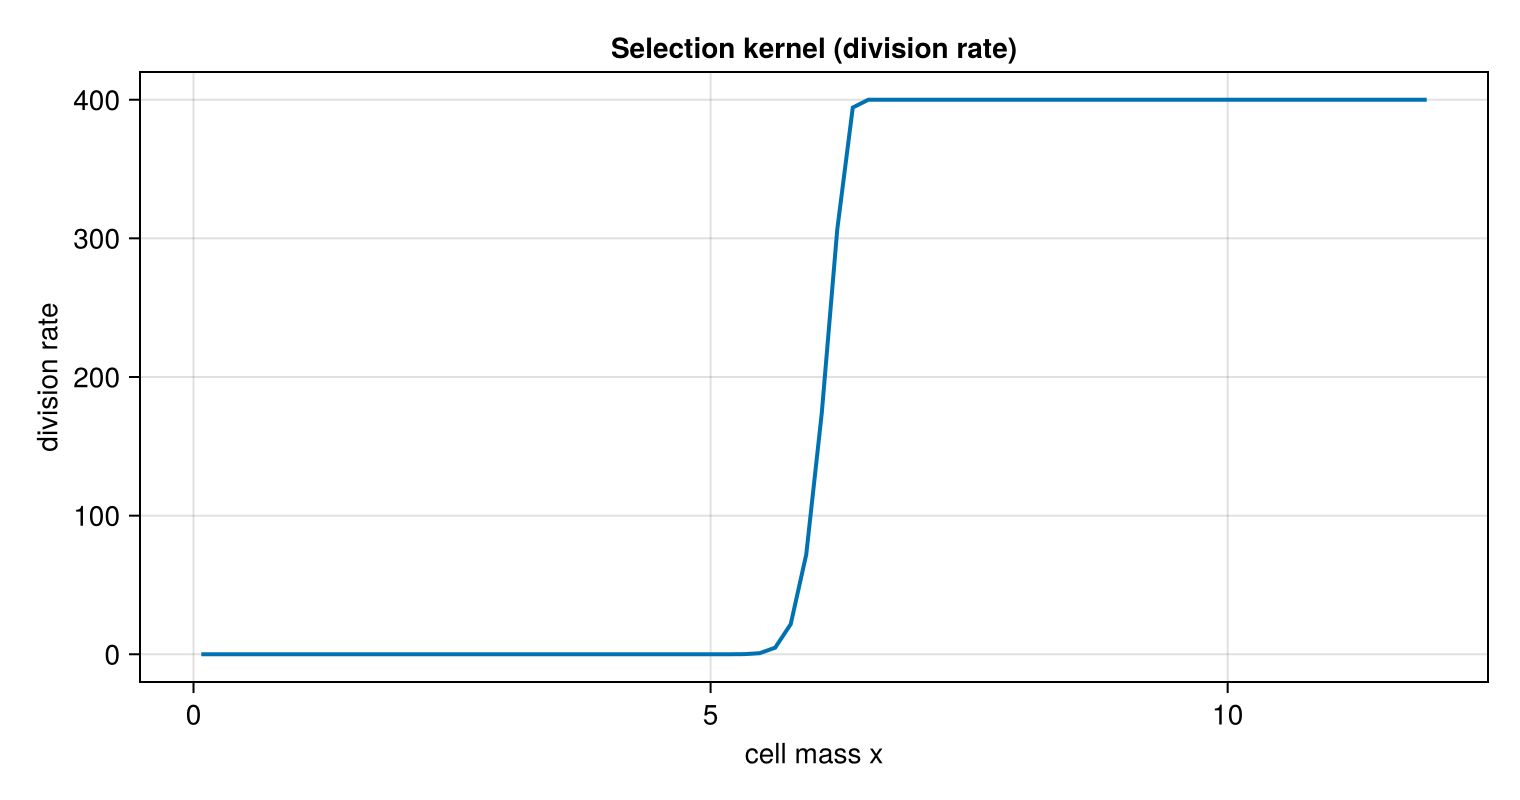

In [3]:
S0 = 1.0
mt, md = m_ts(S0, p), m_ds(S0, p)
sel = [selection(xi, mt, md, p) for xi in x]
fig = Figure(size = (760, 400))
ax = Axis(fig[1, 1], xlabel = "cell mass x", ylabel = "division rate",
          title = "Selection kernel (division rate)")
lines!(ax, x, sel, linewidth = 2)
fig

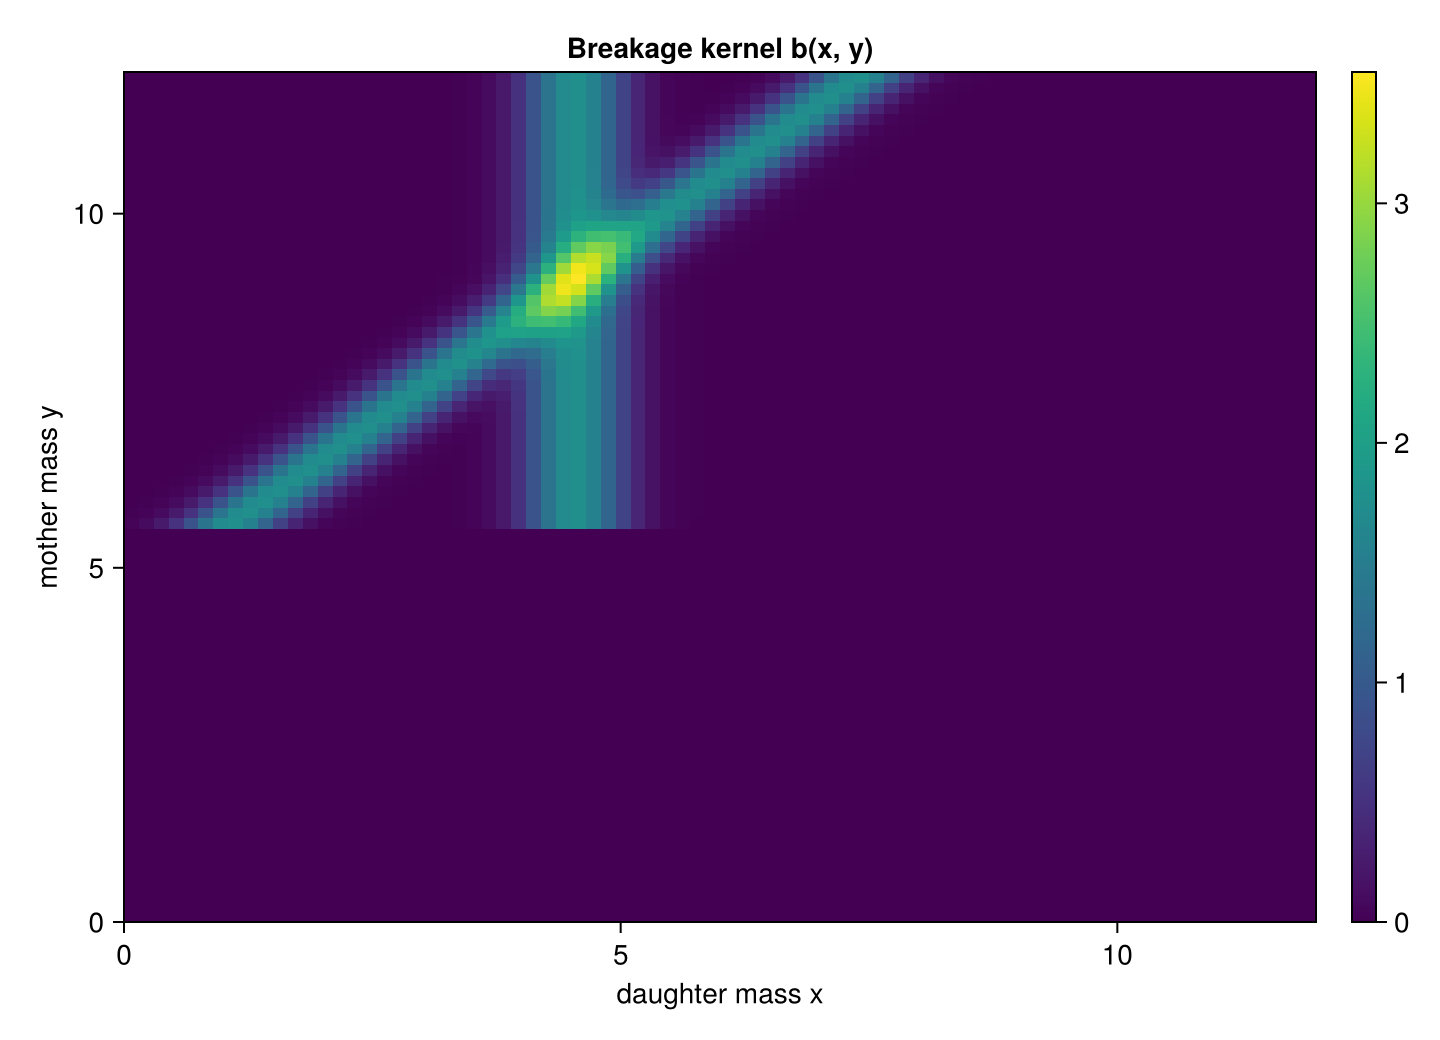

In [4]:
brk = [breakage(xi, yj, mt, p) for xi in x, yj in x]   # [daughter, mother]
fig = Figure(size = (720, 520))
ax = Axis(fig[1, 1], xlabel = "daughter mass x", ylabel = "mother mass y",
          title = "Breakage kernel b(x, y)")
hm = heatmap!(ax, x, x, brk, colormap = :viridis)
Colorbar(fig[1, 2], hm)
fig

## 3. Growth + division in a fixed environment

First, the population balance alone (fixed chemistry). Starting from a narrow low-mass peak, cells **grow up the mass axis** (upwind advection) until they reach the division mass, where they **divide** and daughters are redistributed onto the grid by the Cell Average Technique. The distribution is shown below as a heatmap and as a 3D ridgeline; this isolates and validates the population-balance numerics.

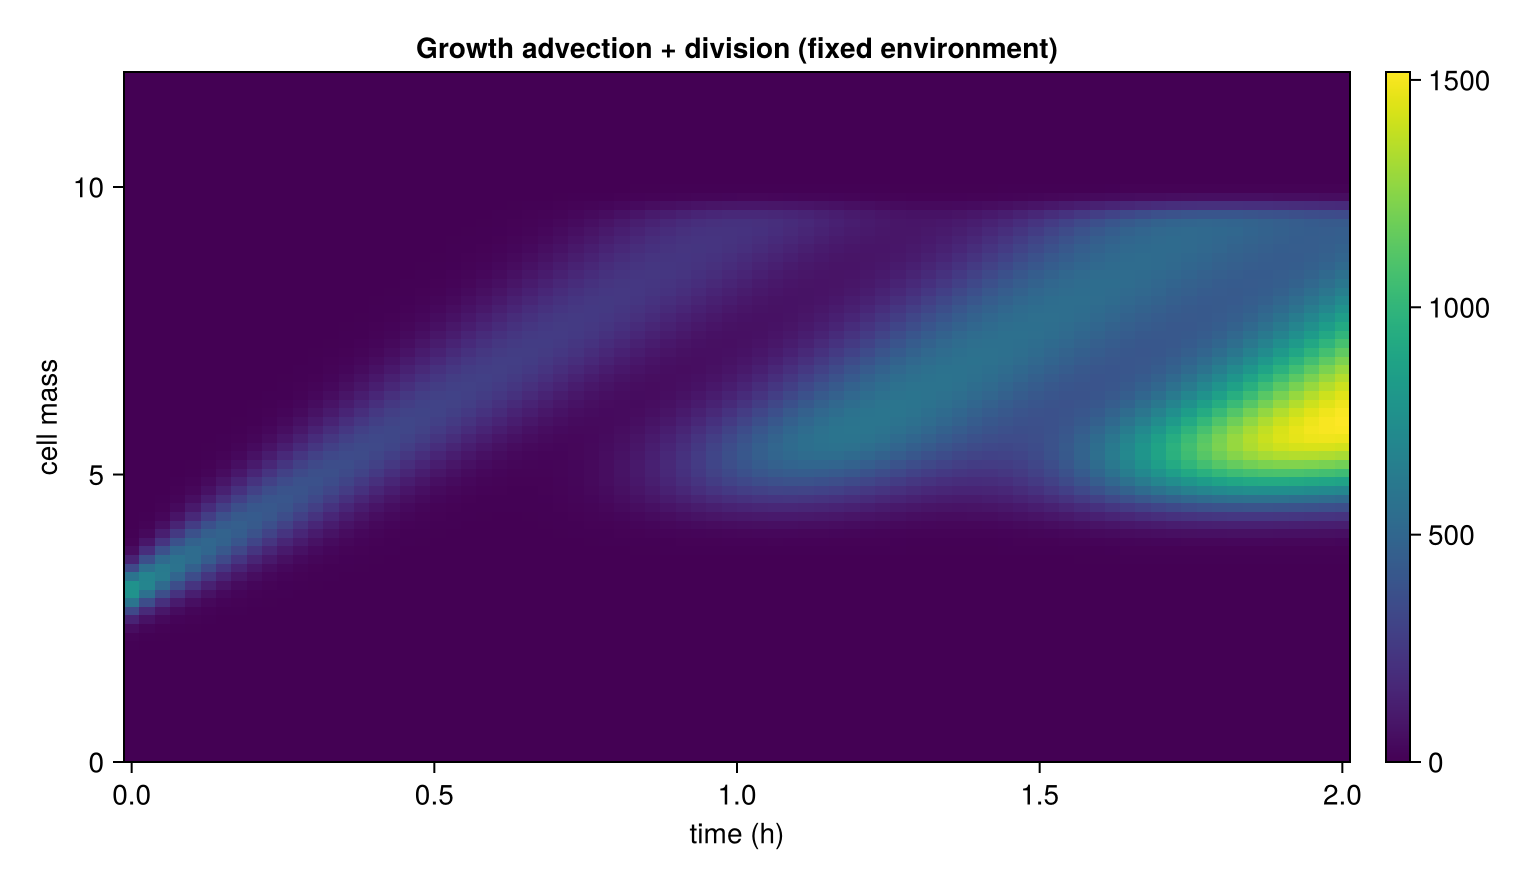

In [5]:
gp = MassGrid(80); xp = gp.centers
N0 = @. 800 * exp(-(xp - 3.0)^2 / 0.4^2)         # narrow low-mass peak
env = ChemState(6.0, 6.0, 0.3, 0.3, 0.05, 0.0, 0.0, 0.0)
outp = solve_population(n = 80, tspan = (0.0, 2.0), saveat = range(0, 2, length = 80),
                        env = env, p = PBEParameters(D = 0.0), N0 = N0)
heatmap_figure(outp.sol.t, xp, outp.sol.u, "Growth advection + division (fixed environment)")

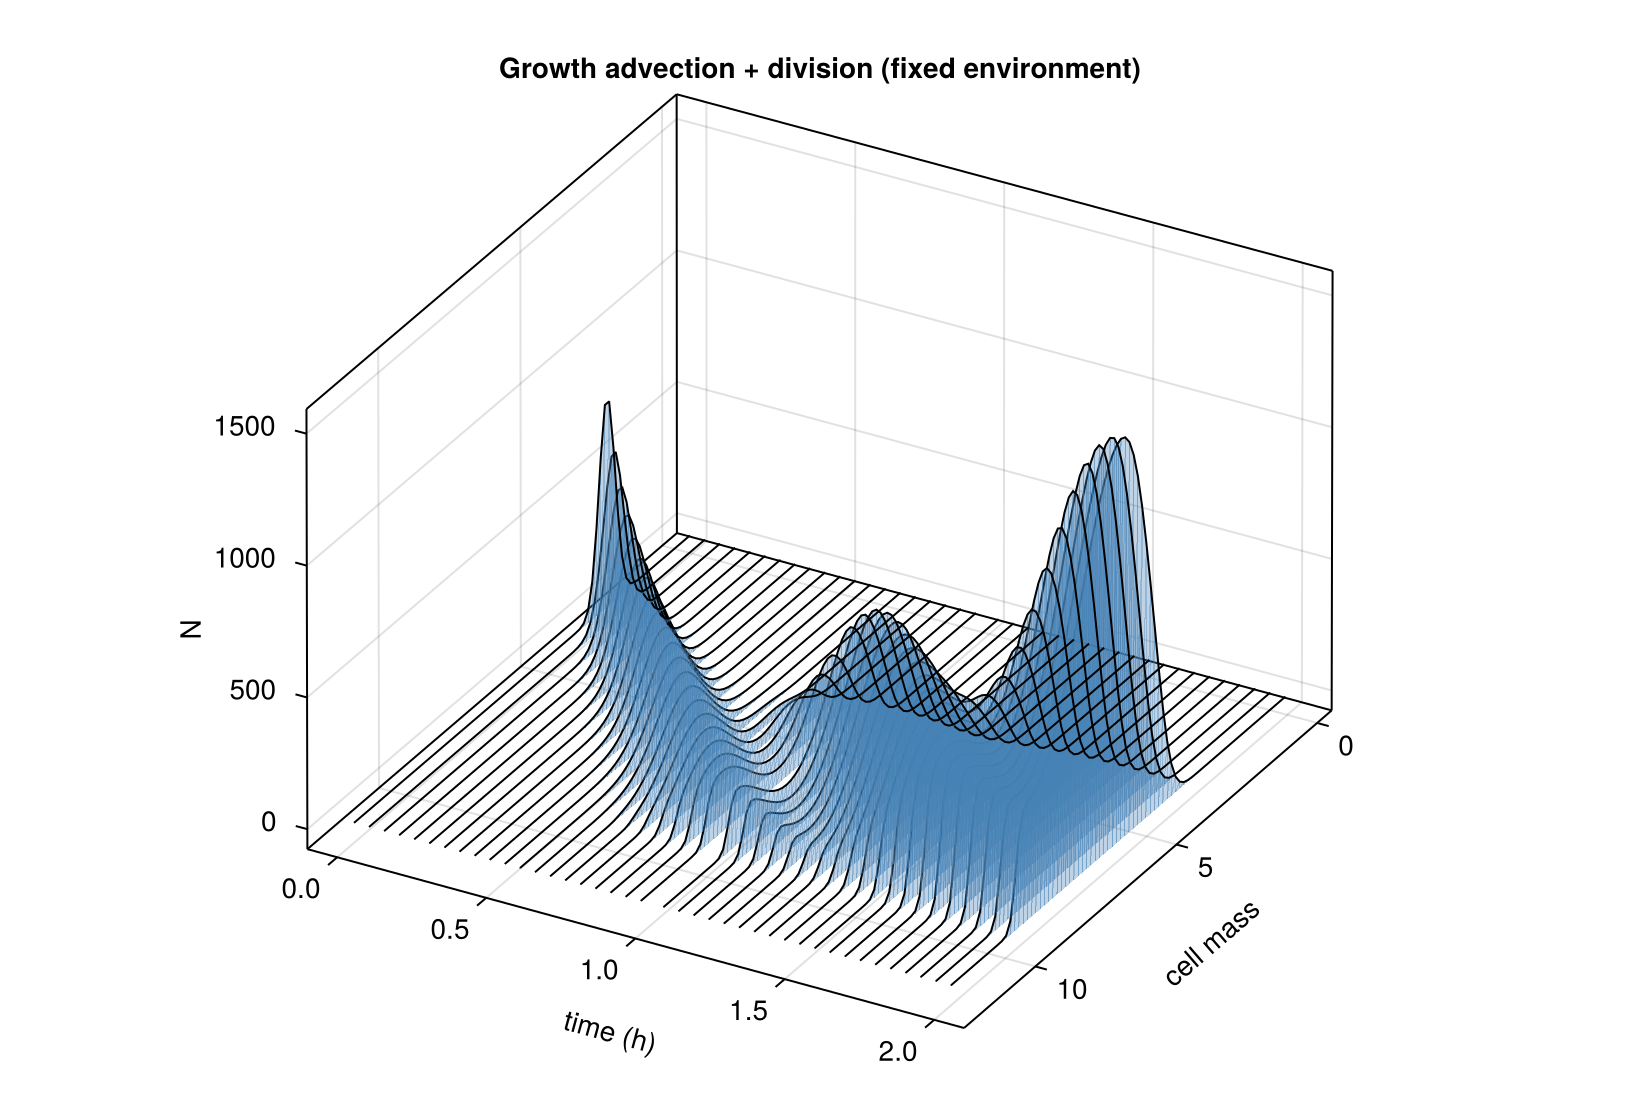

In [6]:
ridge_figure(outp.sol.t, xp, outp.sol.u,
             "Growth advection + division (fixed environment)"; nslice = 40)

## 4. Coupled bioreactor: metabolic oscillations

Now the fully coupled system: the population's substrate uptake feeds back on the chemistry, which in turn sets the growth and division rates. `N_scale` sets the cell-number-to-concentration factor, and a stiff solver handles the gas–liquid mass transfer. The coupled model exhibits the **sustained metabolic oscillations** characteristic of the Henson yeast system — glucose and ethanol cycle out of phase as the population repeatedly grows, depletes substrate, and recovers.

sol.retcode = SciMLBase.ReturnCode.Success


minimum(G) = 0.26319127317993846
maximum(E) = 2.307582140455374


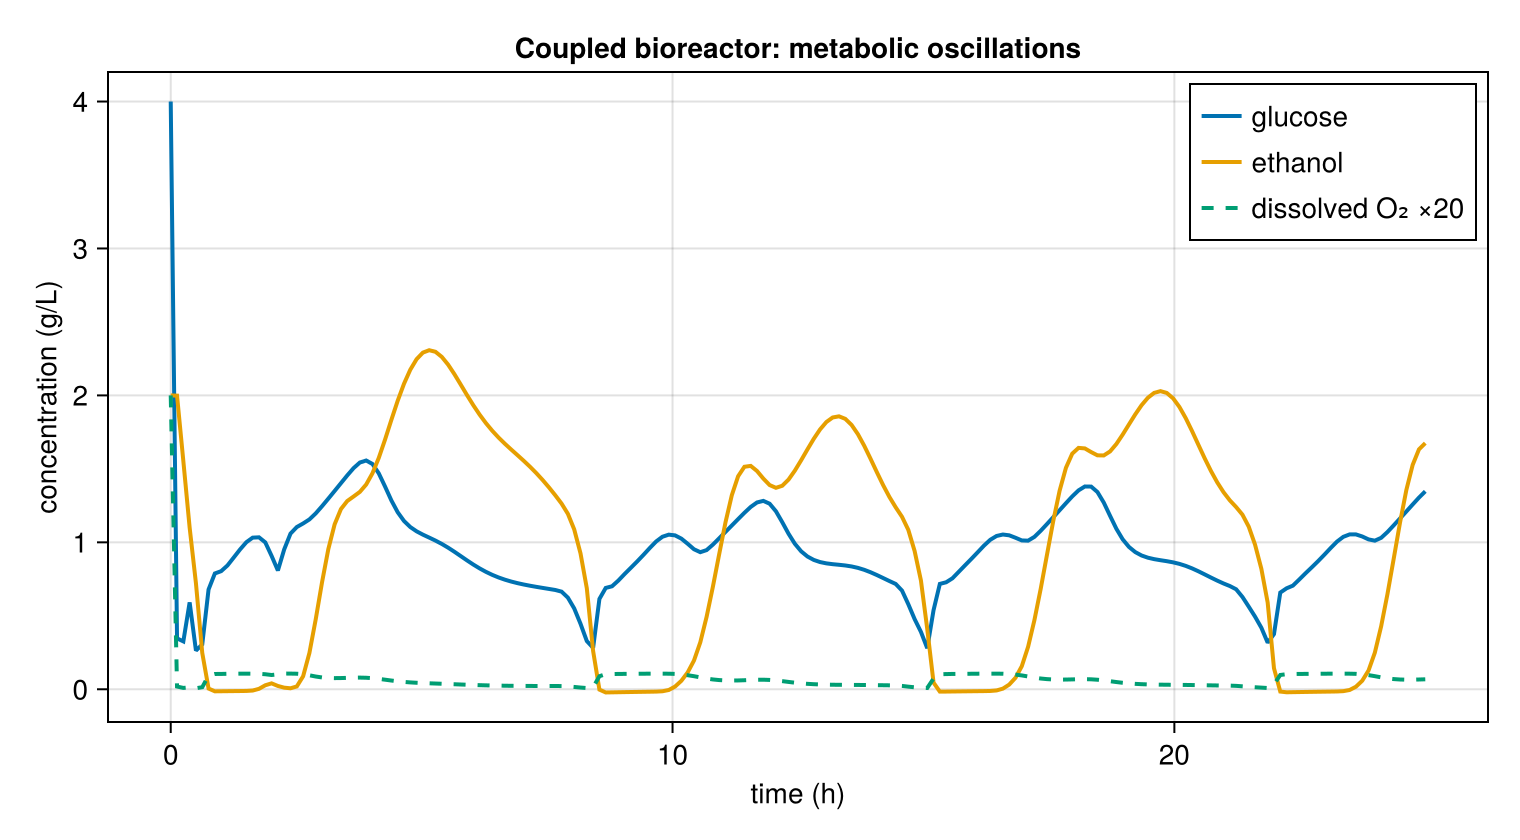

In [7]:
out = solve_pbe(n = 60, tspan = (0.0, 25.0), saveat = range(0, 25, length = 200),
                p = PBEParameters(D = 0.3), N_scale = 1/500)
sol = out.sol; n = out.grid.n; t = sol.t
G = [split_state(u, n)[2].G for u in sol.u]
E = [split_state(u, n)[2].E for u in sol.u]
O = [split_state(u, n)[2].O for u in sol.u]
@show sol.retcode minimum(G) maximum(E)
fig = Figure(size = (760, 420))
ax = Axis(fig[1, 1], xlabel = "time (h)", ylabel = "concentration (g/L)",
          title = "Coupled bioreactor: metabolic oscillations")
lines!(ax, t, G, linewidth = 2, label = "glucose")
lines!(ax, t, E, linewidth = 2, label = "ethanol")
lines!(ax, t, O .* 20, linewidth = 2, linestyle = :dash, label = "dissolved O\u2082 \u00d720")
axislegend(ax)
fig

The cell-size distribution tells the mechanistic story behind the oscillations. Shown as a heatmap and a 3D ridgeline, it reveals cohorts of cells growing up the mass axis, dividing near $m_d \approx 10$, and the daughters (near $m_t \approx 4.5$) starting the cycle again, synchronized with the chemical oscillations.

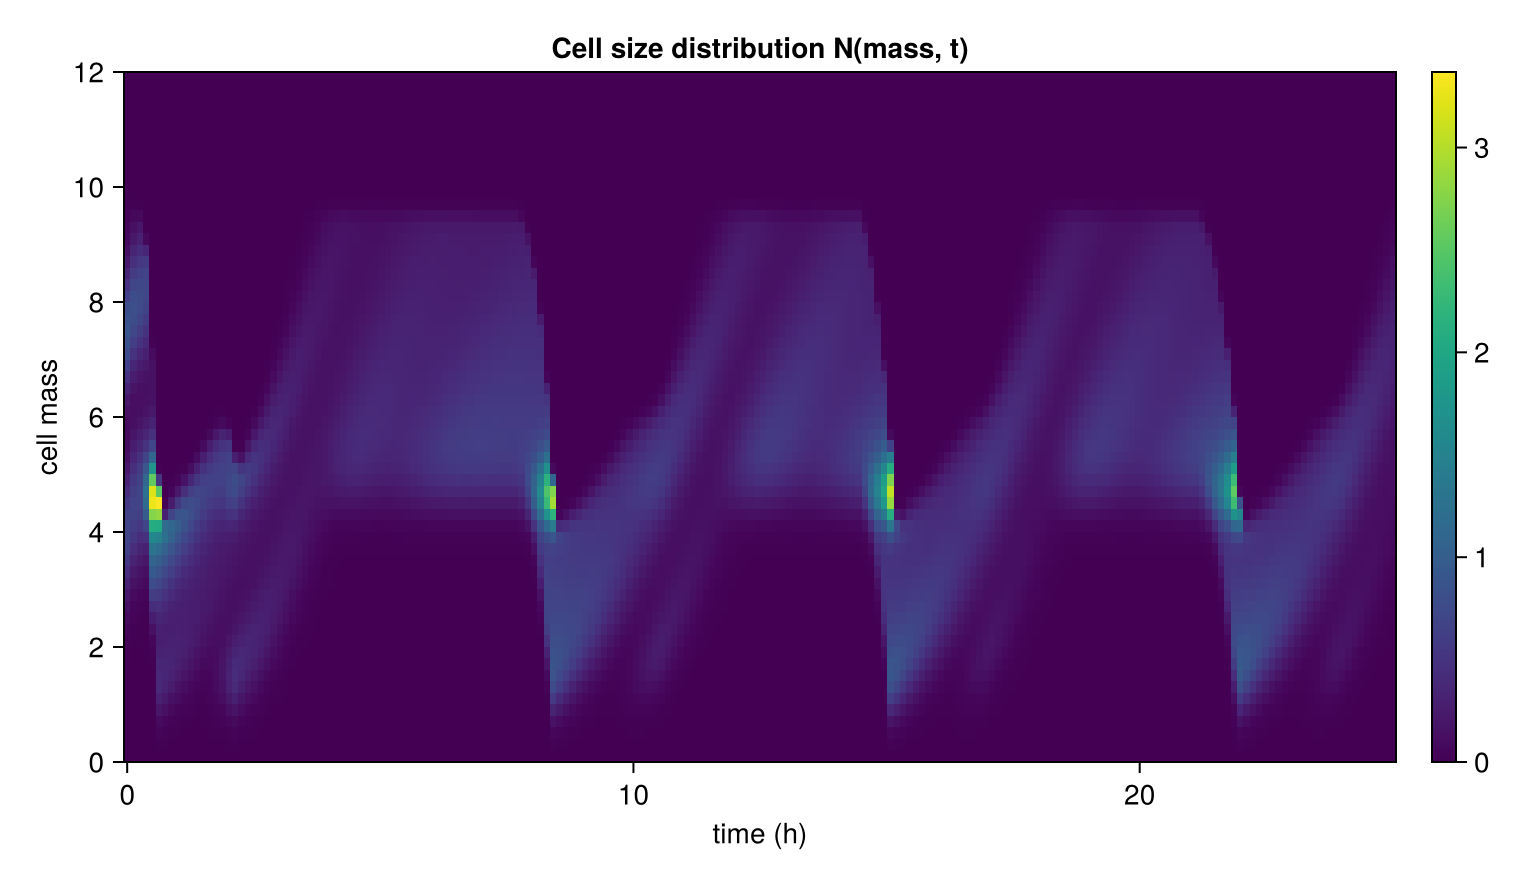

In [8]:
cols = [split_state(u, n)[1] for u in sol.u]
heatmap_figure(t, out.grid.centers, cols, "Cell size distribution N(mass, t)")

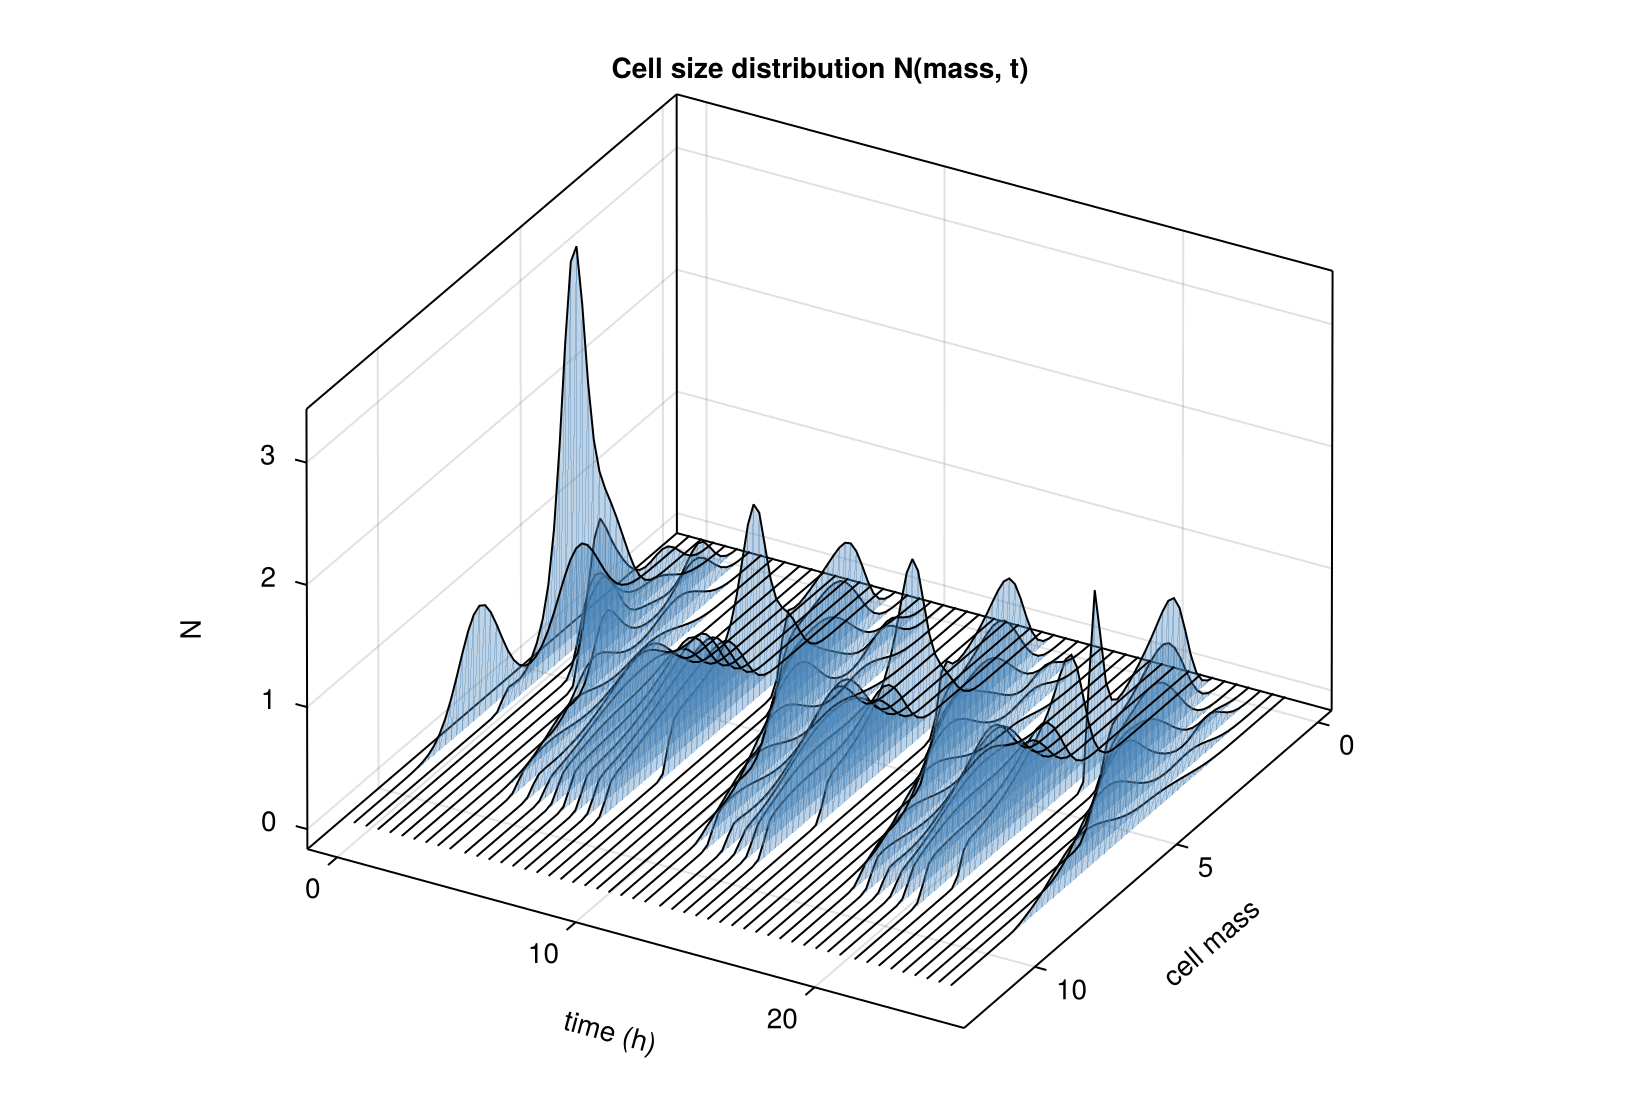

In [9]:
ridge_figure(t, out.grid.centers, cols, "Cell size distribution N(mass, t)"; nslice = 50)

## Numerical methods

- **Division (integro-PDE):** the birth term is a double integral over dividing mothers; newborns of arbitrary mass are redistributed onto the two neighboring grid nodes by the **Cell Average Technique**, keeping number and mass placement consistent on the coarse grid. The inner breakage integrals are evaluated with adaptive Gauss–Kronrod quadrature (`QuadGK`), pruned by skipping cells with zero division rate.
- **Growth (advection):** a first-order **upwind** flux $-\partial(gN)/\partial x$ advects cells up the mass axis.
- **Coupled chemistry:** 8 stiff ODEs (gas–liquid O$_2$/CO$_2$ transfer, substrate uptake integrated over the population by the trapezoidal rule). Solved with `FBDF` (a BDF method) using a finite-difference Jacobian, since the non-smooth division kernels are not amenable to automatic differentiation.
- **Stability:** Monod rates clamp substrate/oxygen concentrations at zero, keeping the fast transient physical.

The package ships with a test suite (`test/runtests.jl`, 26 tests) covering the grid, kernel continuity and gating, Monod kinetics, quadrature, and well-formedness of the right-hand side.